In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

In [3]:
df = df.dropna()

In [4]:
X = df[['horsepower']]
y = df['mpg']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [7]:
y_pred_linear = linear_model.predict(X_test)

In [8]:
mse_linear = mean_squared_error(y_test, y_pred_linear)

In [9]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [10]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [11]:
y_pred_poly = poly_model.predict(X_test_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)


Linear MSE: 22.153237123863413
Polynomial MSE: 18.416967796017616


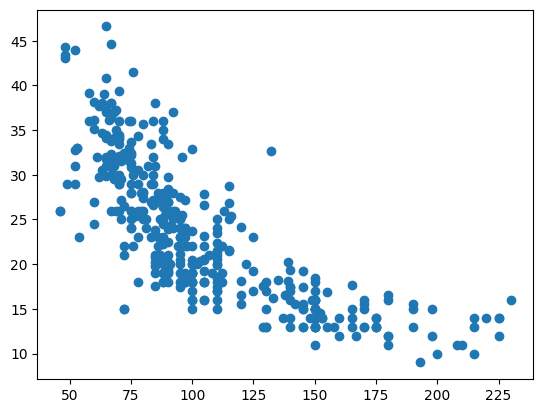

In [12]:
print("Linear MSE:", mse_linear)
print("Polynomial MSE:", mse_poly)

plt.scatter(X, y)


In [13]:
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1,1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


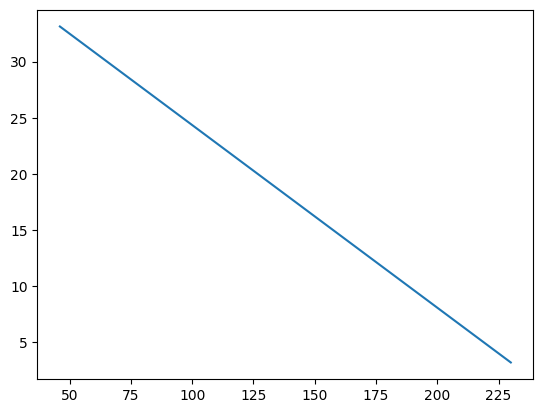

In [14]:
y_linear_plot = linear_model.predict(X_range)
plt.plot(X_range, y_linear_plot)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


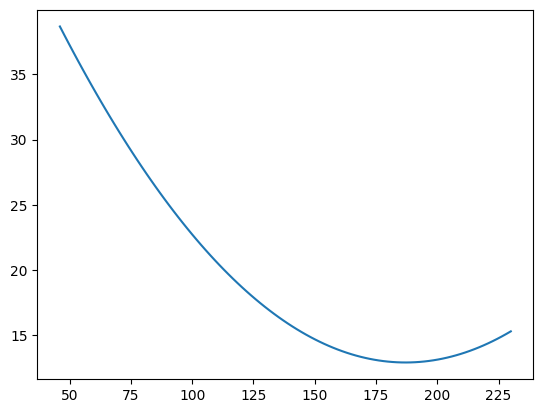

In [15]:
X_range_poly = poly.transform(X_range)
y_poly_plot = poly_model.predict(X_range_poly)
plt.plot(X_range, y_poly_plot)


In [16]:
plt.show()

In [17]:
### Conclusion

#The Auto MPG dataset analysis shows that Linear Regression provides a simple relationship between features and fuel efficiency, but may underfit
#complex patterns. Polynomial Regression captures non-linear relationships better, improving prediction accuracy. This comparison highlights the importance
#of choosing the right model to avoid underfitting and overfitting in regression tasks.
